# Fraud Detection Using Machine Learning

## Import Libraries and Set Random Seed
This section imports all necessary libraries for data processing, visualization, and modeling, and sets a fixed random seed to ensure reproducibility of results.

In [1]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.svm import OneClassSVM
from sklearn.metrics import (confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score, accuracy_score)
from sklearn.utils import resample
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Setup complete.")

Setup complete.


In [2]:
def evaluate_model(model_name, y_true, y_pred, y_proba=None):
  print(f"\n===== {model_name} =====")
  print("\nClassification Report:")
  print(classification_report(y_true, y_pred, digits=4))
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1-score: {f1:.4f}")
  if y_proba is not None:
    auc = roc_auc_score(y_true, y_proba)
    print(f"ROC-AUC: {auc:.4f}")
  cm = confusion_matrix(y_true, y_pred)
  plt.figure(figsize=(6, 4))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
              xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"])
  plt.title(f"Confusion Matrix - {model_name}")
  plt.xlabel("Predicted Label")
  plt.ylabel("Actual Label")
  plt.show()

## Load Dataset
In this step, the fraud detection dataset is loaded into a DataFrame to begin analysis and preprocessing.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = "/content/drive/MyDrive/fraud-detection/fraudTrain.csv"

df_raw = pd.read_csv(path)
print(df_raw.shape)

(1296675, 23)


In [5]:
df = df_raw.copy()
print("Working shape:", df.shape)

Working shape: (1296675, 23)


In [6]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Data Exploration
This section explores the structure and characteristics of the dataset, including data types, distributions, and potential imbalances between fraudulent and non-fraudulent transactions.

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [8]:
print(df["is_fraud"].value_counts())
print("\nPercentage:")
print(df["is_fraud"].value_counts(normalize=True) * 100)

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Percentage:
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


## Feature Engineering
New features are created from existing data, such as extracting time-based variables and calculating age, to improve the model's ability to detect fraud patterns.

In [9]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors = "coerce")
df["dob"] = pd.to_datetime(df["dob"], errors = "coerce")
print(df[["trans_date_trans_time", "dob"]].dtypes)

trans_date_trans_time    datetime64[ns]
dob                      datetime64[ns]
dtype: object


In [10]:
df["hour"]=df["trans_date_trans_time"].dt.hour
df["day"]=df["trans_date_trans_time"].dt.day
df["weekday"]=df["trans_date_trans_time"].dt.weekday
df["age"]=(df["trans_date_trans_time"] - df["dob"]).dt.days // 365

print(df[["hour", "day", "weekday", "age"]].head())

   hour  day  weekday  age
0     0    1        1   30
1     0    1        1   40
2     0    1        1   56
3     0    1        1   52
4     0    1        1   32


## Data Cleaning and Feature Selection
Unnecessary and sensitive columns are removed, and only relevant features are retained to improve model performance and reduce noise.

In [11]:
cols_to_drop = ["Unnamed: 0", "cc_num", "trans_num", "trans_date_trans_time",
                "dob", "first", "last", "street", "city", "state", "zip"]
df=df.drop(columns=cols_to_drop, errors="ignore")
print("Shape after dropping columns:", df.shape)
print("\nRemaining columns:\n", df.columns)

Shape after dropping columns: (1296675, 16)

Remaining columns:
 Index(['merchant', 'category', 'amt', 'gender', 'lat', 'long', 'city_pop',
       'job', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'hour',
       'day', 'weekday', 'age'],
      dtype='object')


In [12]:
X=df.drop("is_fraud", axis=1)
y=df["is_fraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1296675, 15)
y shape: (1296675,)


In [13]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'hour', 'day', 'weekday', 'age']

Categorical features: ['merchant', 'category', 'gender', 'job']


## Train-Test Split
The dataset is split into training and testing sets using stratification to preserve the class distribution of fraudulent and non-fraudulent transactions.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=SEED)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\ny_train distribution:\n", y_train.value_counts())
print("\ny_test distribution:\n", y_test.value_counts())

X_train: (1037340, 15)
X_test: (259335, 15)

y_train distribution:
 is_fraud
0    1031335
1       6005
Name: count, dtype: int64

y_test distribution:
 is_fraud
0    257834
1      1501
Name: count, dtype: int64


## Preprocessing Pipeline
A preprocessing pipeline is built to handle missing values, scale numerical features, and encode categorical variables in a consistent and efficient manner.

In [15]:
#Numeric pipeline
numeric_transformer=Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
#Categorical pipeline
categorical_transformer=Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
#Full preprocessor
preprocessor=ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])
print("Preprocessor ready.")

Preprocessor ready.


## Baseline Model Training and Evaluation
Multiple machine learning models are trained and evaluated using appropriate metrics to compare their performance in detecting fraudulent transactions.

### **Logistic Regression**

In [16]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=SEED
    ))
])
print("Logistic Regression pipeline ready.")

Logistic Regression pipeline ready.


In [17]:
log_reg_pipeline.fit(X_train, y_train)
print("Logistic Regression training complete.")

Logistic Regression training complete.


In [18]:
#Predictions
y_pred_lr = log_reg_pipeline.predict(X_test)
y_proba_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]


===== Logistic Regression =====

Classification Report:
              precision    recall  f1-score   support

           0     0.9945    0.9996    0.9970    257834
           1     0.3810    0.0426    0.0767      1501

    accuracy                         0.9941    259335
   macro avg     0.6877    0.5211    0.5369    259335
weighted avg     0.9909    0.9941    0.9917    259335

Accuracy: 0.9941
Precision: 0.3810
Recall: 0.0426
F1-score: 0.0767
ROC-AUC: 0.8372


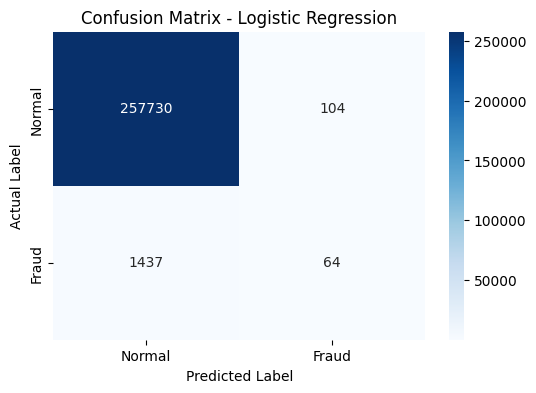

In [19]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_proba_lr
)

The Logistic Regression model performs poorly for fraud detection, with a very low recall (4.26%), meaning it fails to identify most fraudulent transactions. Although the precision is moderate, the model misses a large number of fraud cases, as shown in the confusion matrix. This makes it unsuitable for fraud detection where detecting fraud is critical.

### **Random Forest**

In [20]:
X_rf = X.drop(columns=["merchant", "job"])
numeric_features_rf=X_rf.select_dtypes(include=["number"]).columns.tolist()
categorical_features_rf=X_rf.select_dtypes(include=["object"]).columns.tolist()
print("RF numeric features:", numeric_features_rf)
print("RF categorical features:", categorical_features_rf)
print("X_rf shape:", X_rf.shape)

RF numeric features: ['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'hour', 'day', 'weekday', 'age']
RF categorical features: ['category', 'gender']
X_rf shape: (1296675, 13)


In [21]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)
print("X_train_rf:", X_train_rf.shape)
print("X_test_rf:", X_test_rf.shape)

X_train_rf: (1037340, 13)
X_test_rf: (259335, 13)


In [22]:
numeric_transformer_rf=Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])
categorical_transformer_rf=Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor_rf=ColumnTransformer(transformers=[
    ("num", numeric_transformer_rf, numeric_features_rf),
    ("cat", categorical_transformer_rf, categorical_features_rf)
])

In [23]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(
        n_estimators=50,
        max_depth=12,
        random_state=SEED,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])
print("Random Forest pipeline ready.")

Random Forest pipeline ready.


In [24]:
rf_pipeline.fit(X_train_rf, y_train_rf)
print("Random Forest training complete.")

Random Forest training complete.


In [25]:
# Predictions
y_pred_rf = rf_pipeline.predict(X_test_rf)
y_proba_rf = rf_pipeline.predict_proba(X_test_rf)[:, 1]


===== Random Forest =====

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9888    0.9942    257834
           1     0.3263    0.9334    0.4835      1501

    accuracy                         0.9885    259335
   macro avg     0.6629    0.9611    0.7388    259335
weighted avg     0.9957    0.9885    0.9912    259335

Accuracy: 0.9885
Precision: 0.3263
Recall: 0.9334
F1-score: 0.4835
ROC-AUC: 0.9948


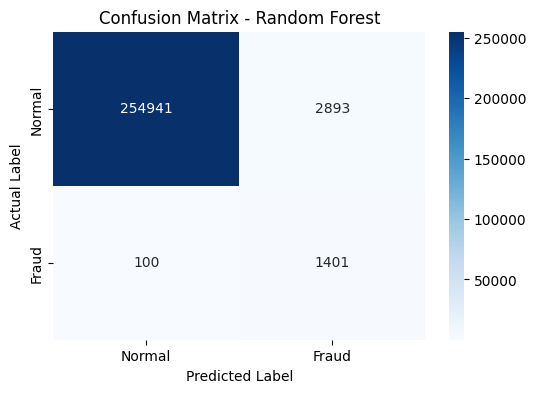

In [26]:
evaluate_model(
    "Random Forest",
    y_test_rf,
    y_pred_rf,
    y_proba_rf
)

The Random Forest model achieved a high recall (93.34%), meaning most fraud cases were correctly detected. However, the precision is low (32.63%), indicating many false positives. This shows the model is effective for detection but may generate many false alarms.

### **XGBoost**

In [27]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=SEED,
        eval_metric="logloss",
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1
    ))
])
print("XGBoost pipeline ready.")

XGBoost pipeline ready.


In [28]:
xgb_pipeline.fit(X_train, y_train)
print("XGBoost training complete.")

XGBoost training complete.


In [29]:
#Predictions
y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]


===== XGBoost =====

Classification Report:
              precision    recall  f1-score   support

           0     0.9989    0.9998    0.9993    257834
           1     0.9538    0.8108    0.8765      1501

    accuracy                         0.9987    259335
   macro avg     0.9763    0.9053    0.9379    259335
weighted avg     0.9986    0.9987    0.9986    259335

Accuracy: 0.9987
Precision: 0.9538
Recall: 0.8108
F1-score: 0.8765
ROC-AUC: 0.9955


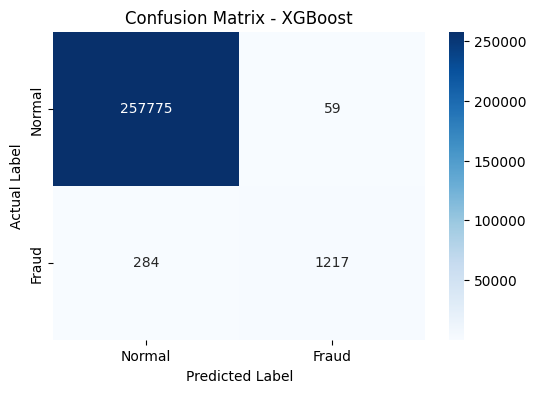

In [30]:
evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_proba_xgb
)

The XGBoost model achieves the best overall performance among all tested models. It maintains a high precision (95.38%), meaning most predicted fraud cases are actually fraudulent, while also achieving a strong recall (81.08%), successfully detecting the majority of fraud cases.

The F1-score (0.8765) indicates a good balance between precision and recall. Additionally, the ROC-AUC score (0.9955) demonstrates excellent ability to distinguish between fraudulent and non-fraudulenet transactions.

Compared to Random Forest, XGBoost significantly reduces false positives while still maintaining high fraud detection capability, making it the most suitable model for this task.

## Feature Importance Analysis
The feature importance analysis shows which variables contribute most to fraud detection. The model relies heavily on certain transaction-related features such as amount, location, and time-based variables.

This indicates that fraud detection is influenced by patterns in transaction behavior rather than personal identifiers. Understanding these important features helps explain how the model makes decisions and provides insight into key fraud indicators.

In [31]:
xgb_model = xgb_pipeline.named_steps["classifier"]
feature_names = xgb_pipeline.named_steps["preprocessor"].get_feature_names_out()

In [32]:
importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

In [33]:
feature_importance_df.head(20)

,feature,importance
708,cat__category_grocery_pos,0.490447
7,num__hour,0.213589
706,cat__category_gas_transport,0.138852
0,num__amt,0.021609
10,num__age,0.009699
6,num__merch_long,0.007862
717,cat__category_travel,0.007136
704,cat__category_entertainment,0.006545
710,cat__category_home,0.004902
718,cat__gender_F,0.003150


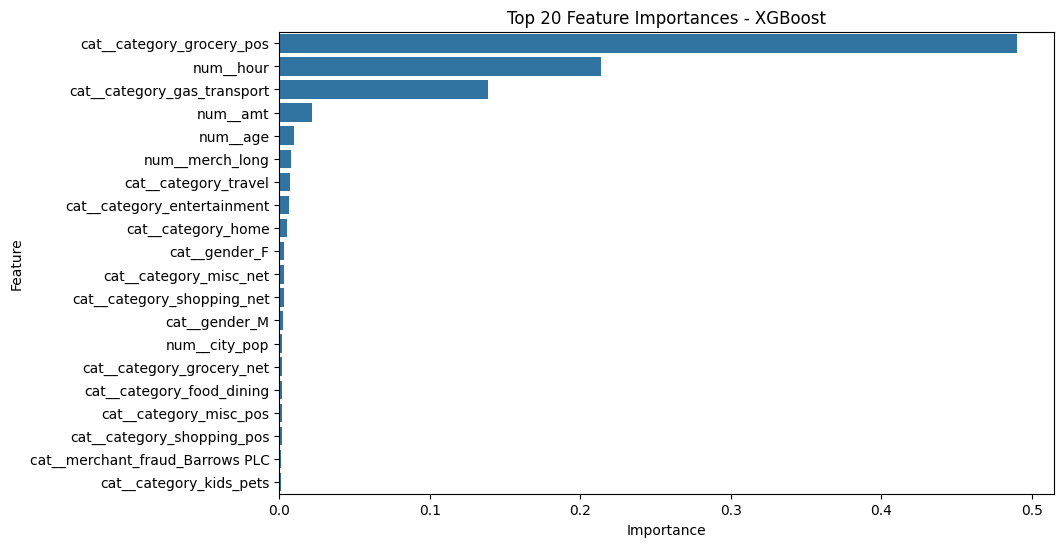

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(20),
    x="importance",
    y="feature"
)
plt.title("Top 20 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance analysis reveals that transaction category is the most influential factor in detecting fraud, with certain categories such as grocery and gas-related transactions having a strong impact on the model's predictions.

Time-related features, particularly the transaction hour, also play a significant role, indicating that fraudulent activity tends to occur at specific times. Interestingly, the transaction amount has relatively low importance, suggesting that fraud detection depends more on behavioral patterns than on transaction size alone.

These results highlight that fraud detection is driven by patterns in transaction type and timing rather than simple numerical thresholds.

### **Isolation Forest**

In [35]:
#Fit preprocessing on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print("Processed shapes:")
print("X_train:", X_train_processed.shape)
print("X_test:", X_test_processed.shape)

Processed shapes:
X_train: (1037340, 1214)
X_test: (259335, 1214)


In [36]:
#Keep only normal training data
X_train_normal = X_train_processed[(y_train == 0).values]
print("Normal-only training shape:", X_train_normal.shape)

Normal-only training shape: (1031335, 1214)


In [37]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=float(y_train.mean()),
    random_state=SEED,
    n_jobs=-1
)
iso_forest.fit(X_train_normal)
print("Isolation Forest training complete.")

Isolation Forest training complete.


In [38]:
iso_pred_raw = iso_forest.predict(X_test_processed)
print("Unique raw predictions:", np.unique(iso_pred_raw, return_counts=True))

Unique raw predictions: (array([-1,  1]), array([  1608, 257727]))


In [39]:
#Convert Isolation Forest output to fraud labels
iso_pred=np.where(iso_pred_raw == -1, 1, 0)


===== Isolation Forest =====

Classification Report:
              precision    recall  f1-score   support

           0     0.9945    0.9940    0.9942    257834
           1     0.0442    0.0473    0.0457      1501

    accuracy                         0.9886    259335
   macro avg     0.5193    0.5207    0.5200    259335
weighted avg     0.9890    0.9886    0.9888    259335

Accuracy: 0.9886
Precision: 0.0442
Recall: 0.0473
F1-score: 0.0457


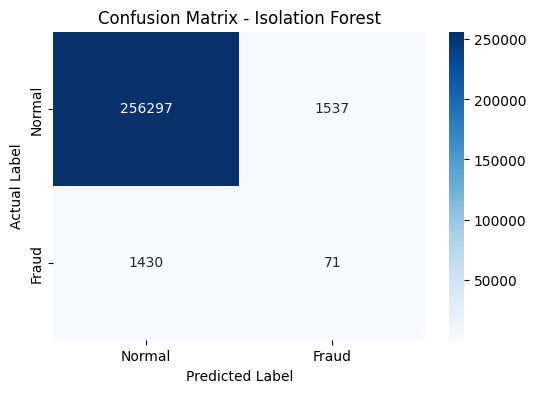

In [40]:
evaluate_model(
    "Isolation Forest",
    y_test,
    iso_pred
)

The Isolation Forest model performs poorly for fraud detection, with very low precision and recall. It fails to correctly identify most fraudulent transactions and produces many incorrect predictions.

This indicates that the model struggles to distinguish between normal and fraudulent behavior in this dataset. Unlike supervised models, Isolation Forest does not use labeled data during training, which limits its ability to accurately detect fraud patterns.

### **One-Class SVM**

In [41]:
X_train_normal_sample = resample(
    X_train_normal,
    replace=False,
    n_samples=50000,
    random_state=SEED
)
print("Sampled normal data shape:", X_train_normal_sample.shape)

Sampled normal data shape: (50000, 1214)


In [42]:
ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=float(y_train.mean())
)
ocsvm.fit(X_train_normal_sample)
print("One-Class SVM training complete.")

One-Class SVM training complete.


In [43]:
ocsvm_pred_raw = ocsvm.predict(X_test_processed)
print("Unique raw predictions:", np.unique(ocsvm_pred_raw, return_counts=True))

Unique raw predictions: (array([-1,  1]), array([  2657, 256678]))


In [44]:
#Convert One-Class SVM output to fraud labels
ocsvm_pred = np.where(ocsvm_pred_raw == -1, 1, 0)


===== One-Class SVM =====

Classification Report:
              precision    recall  f1-score   support

           0     0.9956    0.9911    0.9934    257834
           1     0.1393    0.2465    0.1780      1501

    accuracy                         0.9868    259335
   macro avg     0.5674    0.6188    0.5857    259335
weighted avg     0.9906    0.9868    0.9886    259335

Accuracy: 0.9868
Precision: 0.1393
Recall: 0.2465
F1-score: 0.1780


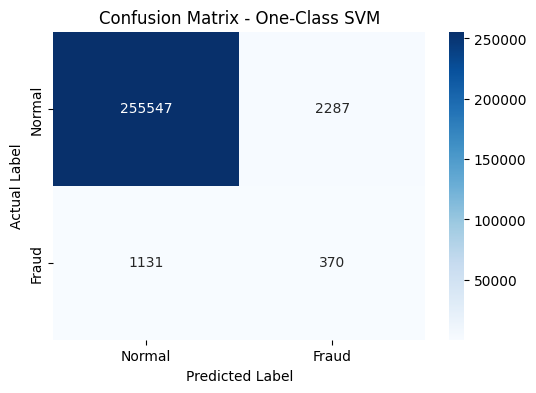

In [45]:
evaluate_model(
    "One-Class SVM",
    y_test,
    ocsvm_pred
)

The One-Class SVM model performs slightly better than Isolation Forest but remains significantly weaker than supervised models. While it detects more fraud cases than Isolation Forest, its recall (24.65%) is still low, meaning many fraudulent transactions are missed.

Additionally, the precision is also low, indicating a high number of false positives. Overall, the model is not suitable for accurate fraud detection compared to supervised approaches.

## Cross-Validation Evaluation
Cross-validation is used to evaluate model performance more reliably by splitting the data into multiple subsets. Stratified K-Fold ensures that each fold maintains the same proportion of fraudulent and non-fraudulent transactions, which is important due to class imbalance.

In [46]:
from sklearn.model_selection import StratifiedKFold, cross_validate
# 5-Fold Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)
#Metrics to evaluate
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [47]:
log_reg_cv_results = cross_validate(
    log_reg_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)
print("Logistic Regression Cross-Validation Results:")
for metric in scoring:
  scores = log_reg_cv_results[f"test_{metric}"]
  print(f"{metric}: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression Cross-Validation Results:
accuracy: 0.9941 ± 0.0001
precision: 0.3892 ± 0.0495
recall: 0.0477 ± 0.0068
f1: 0.0850 ± 0.0119
roc_auc: 0.8348 ± 0.0110


The cross-validation results confirm that Logistic Regression performs poorly for fraud detection. The recall remains very low (~4.77%), meaning the model consistently fails to detect fraudulent transactions across different data splits.

The low standard deviation indicates that the model's performance is stable, but consistently weak. This confirms that Logistic Regression is not suitable for this task, especially due to the highly imbalanced nature of the dataset.

In [48]:
xgb_cv_results = cross_validate(
    xgb_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)
print("XGBoost Cross-Validation Results:")
for metric in scoring:
  scores = xgb_cv_results[f"test_{metric}"]
  print(f"{metric}: {scores.mean():.4f} ± {scores.std():.4f}")

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


XGBoost Cross-Validation Results:
accuracy: 0.9987 ± 0.0000
precision: 0.9511 ± 0.0044
recall: 0.8103 ± 0.0041
f1: 0.8750 ± 0.0026
roc_auc: 0.9961 ± 0.0020


The cross-validation results confirm that XGBoost is the most effective model for fraud detection. It achieves consistently high precision and recall across all folds, indicating a strong ability to detect fraudulent transactions while minimizing false positives.

The very low standard deviation across all metrics shows that the model's performance is highly stable and not dependent on a specific data split. This demonstrates that XGBoost generalizes well and is reliable for real-world fraud detection tasks.


## PCA Implementation
Principal Component Analysis (PCA) is applied after preprocessing to reduce the dimensionality of the dataset while preserving most of the information. This helps in simplifying the model and potentially improving performance and computational efficiency.

PCA was applied only to numerical features after imputation and scaling. Categorical features were still encoded using OneHotEncoder. This approach avoids applying PCA directly to sparse one-hot encoded data while still satisfying the dimensionality reduction requirement.

In [49]:
numeric_transformer_pca = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=SEED))
])
categorical_transformer_pca = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor_pca = ColumnTransformer(transformers=[
    ("num_pca", numeric_transformer_pca, numeric_features),
    ("cat", categorical_transformer_pca, categorical_features)
])

In [50]:
pca_xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_pca),
    ("classifier", XGBClassifier(
        random_state=SEED,
        eval_metric="logloss",
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1
    ))
])


===== XGBoost with PCA =====

Classification Report:
              precision    recall  f1-score   support

           0     0.9981    0.9996    0.9988    257834
           1     0.9010    0.6789    0.7743      1501

    accuracy                         0.9977    259335
   macro avg     0.9496    0.8392    0.8866    259335
weighted avg     0.9976    0.9977    0.9975    259335

Accuracy: 0.9977
Precision: 0.9010
Recall: 0.6789
F1-score: 0.7743
ROC-AUC: 0.9908


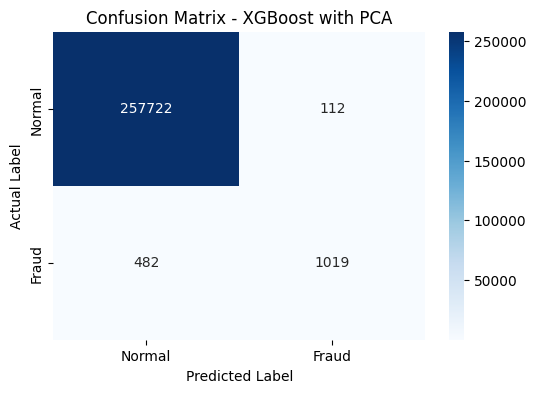

In [51]:
pca_xgb_pipeline.fit(X_train, y_train)
y_pred_pca_xgb = pca_xgb_pipeline.predict(X_test)
y_proba_pca_xgb = pca_xgb_pipeline.predict_proba(X_test)[:, 1]

evaluate_model(
    "XGBoost with PCA",
    y_test,
    y_pred_pca_xgb,
    y_proba_pca_xgb
)

Applying PCA to the dataset resulted in a decrease in model performance. While PCA helps reduce dimensionality, it also removes some important information that is useful for detecting fraud patterns.

In particular, the recall dropped significantly, meaning that more fraudulent transactions were missed. This suggests that PCA is not beneficial for this dataset, as the original feature space contains important details required for accurate fraud detection.

Therefore, the model without PCA remains the preferred approach.

In [52]:
pca_log_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_pca),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED))
])

In [53]:
pca_log_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_pca',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=0.95,
                                                                       random_state=42))]),
                                                  ['amt', 'lat', 'long',
                                                   'city_pop', 'unix_time',
                                                   'merch_lat', 'merch_long',
                                                   'hour', 'day', 'weekday',
                                                   'age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['merchant', 'category',
                                                   'gender', 'job'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [54]:
y_pred_pca_log = pca_log_pipeline.predict(X_test)
y_proba_pca_log = pca_log_pipeline.predict_proba(X_test)[:, 1]


===== Logistic Regression with PCA =====

Classification Report:
              precision    recall  f1-score   support

           0     0.9945    0.9996    0.9970    257834
           1     0.4035    0.0460    0.0825      1501

    accuracy                         0.9941    259335
   macro avg     0.6990    0.5228    0.5398    259335
weighted avg     0.9911    0.9941    0.9917    259335

Accuracy: 0.9941
Precision: 0.4035
Recall: 0.0460
F1-score: 0.0825
ROC-AUC: 0.8368


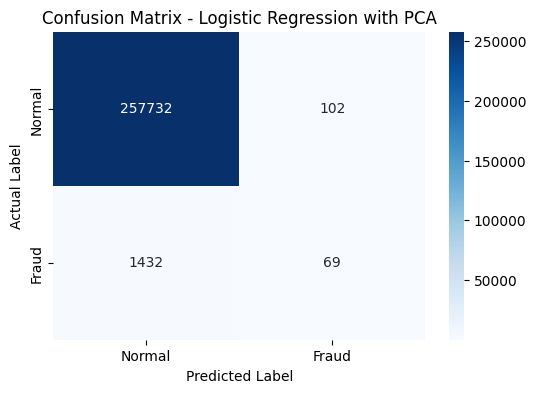

In [55]:
evaluate_model(
    "Logistic Regression with PCA",
    y_test,
    y_pred_pca_log,
    y_proba_pca_log
)

Applying PCA to Logistic Regression resulted in only a minimal improvement in performance. The recall and F1-score increased slightly, but the model still fails to detect most fraudulent transactions.

This indicates that dimensionality reduction alone cannot compensate for the limitations of simple models when dealing with complex and imbalanced datasets. Logistic Regression remains unsuitable for fraud detection even after applying PCA.

## Visualizations
### Model Comparison Bar Chart
Accuracy is not a reliable metric for this problem due to class imbalance, so the comparison focuses on precision, recall and F1-score.

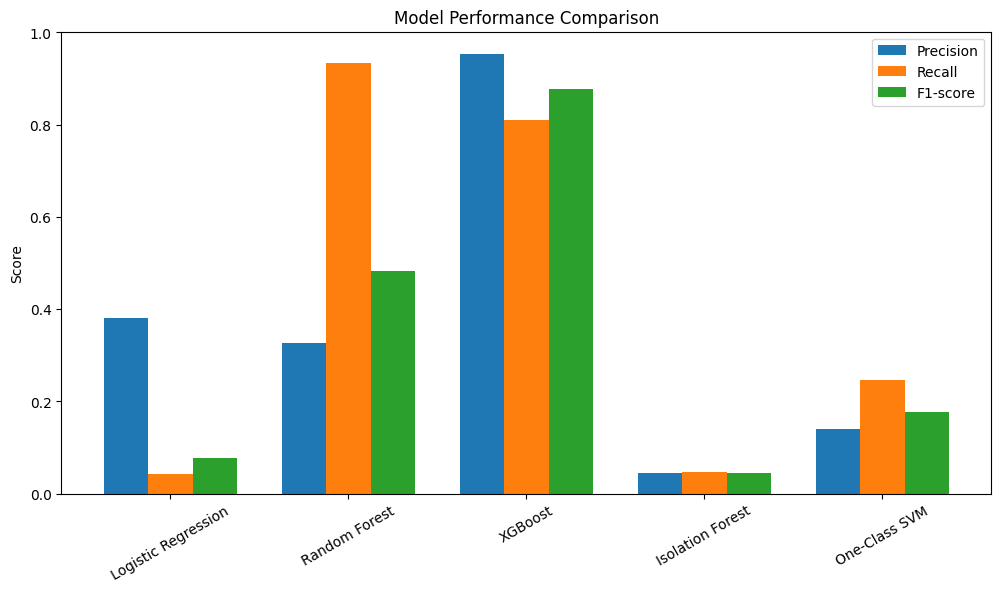

In [56]:
model_names = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
    "Isolation Forest",
    "One-Class SVM"
]
precision = [0.3810, 0.3263, 0.9538, 0.0442, 0.1393]
recall = [0.0426, 0.9334, 0.8108, 0.0473, 0.2465]
f1 = [0.0767, 0.4835, 0.8765, 0.0457, 0.1780]
x = np.arange(len(model_names))
width = 0.25
plt.figure(figsize=(12, 6))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')
plt.xticks(x, model_names, rotation=30)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

This visualization compares model performance across precision, recall and F1-score. It highlights that XGBoost provides the best balance, while other models either fail to detect fraud or generate excessive false positives.

### ROC Curve (for top models)
The ROC curve compares the ability of models to distinguish between fraudulent and non-fraudulent transactions.

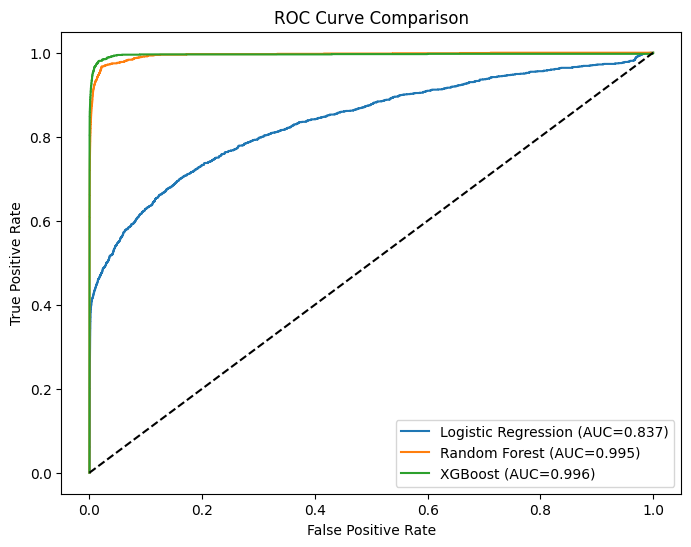

In [57]:
plt.figure(figsize=(8,6))
#Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_proba_lr):.3f})")
#Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test_rf, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test_rf, y_proba_rf):.3f})")
#XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_score(y_test, y_proba_xgb):.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

XGBoost achieves the highest AUC, confirming its superior classification capability.

### Fraud Distribution
The dataset is highly imbalanced, with significantly fewer fraudulent transactions. This imbalance makes fraud detection challenging and justifies the use of metrics such as recall and F1-score instead of accuracy.

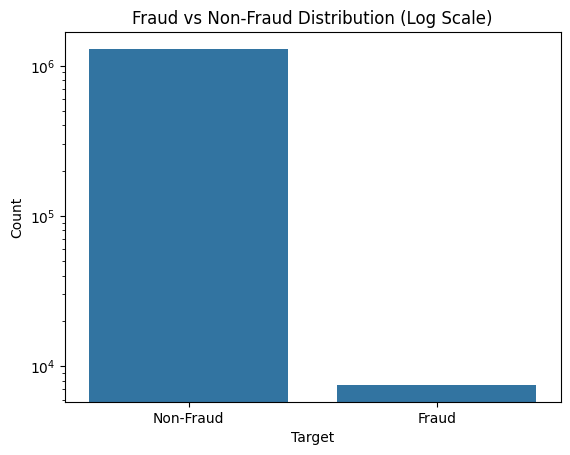

In [58]:
sns.countplot(x=y)
plt.yscale('log')
plt.title("Fraud vs Non-Fraud Distribution (Log Scale)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.xticks([0,1], ["Non-Fraud", "Fraud"])
plt.show()

## Business Cost-Based Model Evaluation
In fraud detection, different types of errors have different business impacts. A false negative means a fraudulent transaction was missed, which can lead to financial loss. A false positive means a normal transaction was incorrectly flagged as fraud, which may cause customer inconvenience and additional review cost.

Therefore, models are also compared using a simple cost-sensitive evaluation:

Total Cost = (False Negatives x Cost of False Negative) + (False Positives x Cost of False Positive)

In this project, the false negative is set higher than the false positive cost because missing fraud is considered more expensive than reviewing a normal transaction.

In [59]:
def calculate_business_cost(y_true, y_pred, cost_fn=100, cost_fp=5):
  cm = confusion_matrix(y_true, y_pred)
  tn, fp, fn, tp = cm.ravel()
  total_cost = (fn * cost_fn) + (fp * cost_fp)
  return {
      "False Positives":fp,
      "False Negatives": fn,
      "Total Cost": total_cost
  }

In [60]:
business_cost_results = []
business_cost_results.append({
    "Model":"Logistic Regression",
    **calculate_business_cost(y_test, y_pred_lr)
})
business_cost_results.append({
    "Model":"Random Forest",
    **calculate_business_cost(y_test_rf, y_pred_rf)
})
business_cost_results.append({
    "Model":"XGBoost",
    **calculate_business_cost(y_test, y_pred_xgb)
})
business_cost_results.append({
    "Model":"Isolation Forest",
    **calculate_business_cost(y_test, iso_pred)
})
business_cost_results.append({
    "Model":"One-Class SVM",
    **calculate_business_cost(y_test, ocsvm_pred)
})
cost_df = pd.DataFrame(business_cost_results)
cost_df.sort_values(by="Total Cost")

,Model,False Positives,False Negatives,Total Cost
1,Random Forest,2893,100,24465
2,XGBoost,59,284,28695
4,One-Class SVM,2287,1131,124535
0,Logistic Regression,104,1437,144220
3,Isolation Forest,1537,1430,150685


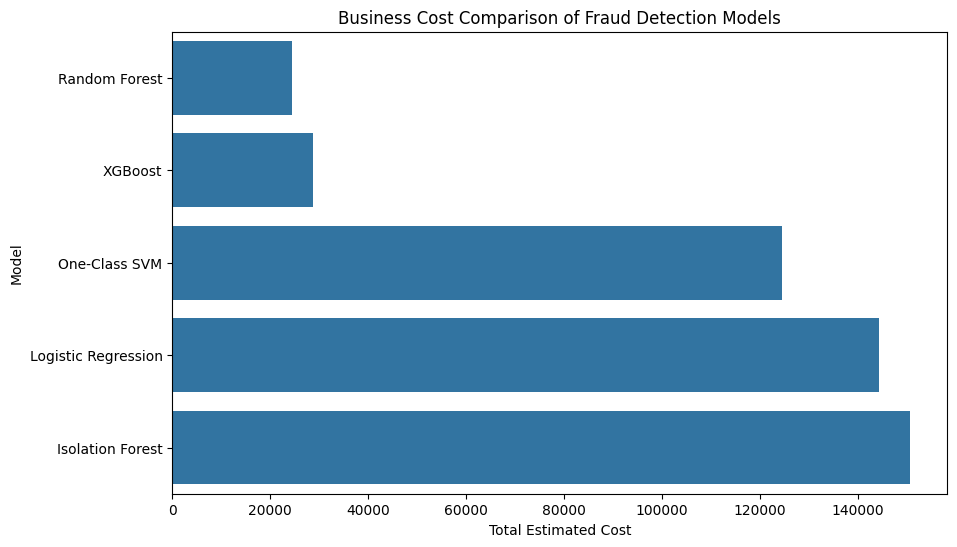

In [61]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=cost_df.sort_values(by="Total Cost"),
    x="Total Cost",
    y="Model"
)
plt.title("Business Cost Comparison of Fraud Detection Models")
plt.xlabel("Total Estimated Cost")
plt.ylabel("Model")
plt.show()

The business cost-based evaluation compares the models using estimated costs for false positives and false negatives. In this project, false negatives were assigned a higher cost because missing a fraudulent transaction can lead to financial loss, while false positives mainly cause inconvenience or additional review.

Based on this cost assumption, Random Forest achieved the lowest total estimated cost because it missed the fewest fraud cases. Although Random Forest produced more false positives than XGBoost, its lower number of false negatives reduced the overall cost.

XGBoost still remains the best model based on traditional machine learning metrics such as precision, F1-score and ROC-AUC. However, this cost-based analysis shows that the best model can change depending on the business objective. If the main goal is to minimize false alarms, XGBoost is preferred. If the main goal is to reduce financial loss from missed fraud, Random Forest may be more suitable.


## Key Findings
The main findings of this project are:
- Accuracy is not sufficient for evaluating fraud detection models because the dataset is highly imbalanced.
- Logistic Regression performed poorly because it failed to detect most fraudulent transactions.
- Unsupervised anomaly detection models, such as Isolation Forest and One-Class SVM, were weaker than supervised models.
- Random Forest achieved the highest recall and the lowest business cost, meaning it missed the fewest fraud cases.
- XGBoost achieved the best overall machine learning performance, with the strongest balance between precision, recall, F1-score and ROC-AUC.
- PCA did not improve performance, suggesting that the original feature space contains important fraud-related patterns.
- Feature importance showed that transaction category and transaction time were among the most influential indicators of fraud.

## Conclusion
This project explored multiple machine learning approaches for fraud detection using a highly imbalanced transaction dataset. Several supervised and unsupervised models were implemented and compared using appropriate evaluation metrics, including precision, recall, F1-score, ROC-AUC and confusion matrices.

The results showed that XGBoost achieved the best overall machine learning performance, with a strong balance between precision and recall and a very high ROC-AUC score. Cross-validation also confirmed that XGBoost produced stable and reliable results across different data splits.

Random Forest achieved the highest recall and the lowest business cost under the cost-sensitive evaluation, meaning it missed fewer fraudulent transactions. This shows that the best model can depend on the objective: XGBoost is preferred when balancing accuracy and false alarms, while Random Forest may be preferred when minimizing the cost of missed fraud is the priority.

The PCA experiment showed that dimensionality reduction did not improve performance, suggesting that the original features contain important fraud-related patterns. Feature importance analysis also showed that transaction category and transaction time were key indicators of fraud.

Overall, the project demonstrates that advanced supervised learning models are more effective than simple or unsupervised approaches for fraud detection, especially when labeled data is available.